In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


2026-02-07 07:08:54.729041: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
keras.utils.set_random_seed(42)
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
df.shape
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [3]:
df.target.value_counts(normalize=True,dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

In [4]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']
df = pd.get_dummies(df,columns=categorical_variables)
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [5]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)
train_df.shape
test_df.shape

(61, 30)

In [6]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()
means
train_df[numerics] = (train_df[numerics] - means)/sd
test_df[numerics] = (test_df[numerics] - means)/sd
train_df.head()


,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [26]:
train = train_df.to_numpy(dtype=np.float32)
test = test_df.to_numpy(dtype=np.float32)

train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

train_Y = train[:,6]
test_Y = test[:,6]

train_X.shape, test_X.shape, train_Y.shape, test_Y.shape

((242, 29), (61, 29), (242,), (61,))

In [27]:
num_columns = train_X.shape[1]

input = keras.Input(shape=(num_columns,))
hidden = keras.layers.Dense(16,activation="relu",name="Hidden")(input)
output = keras.layers.Dense(1,activation="sigmoid",name ="output")(hidden)
model = keras.Model(input,output)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

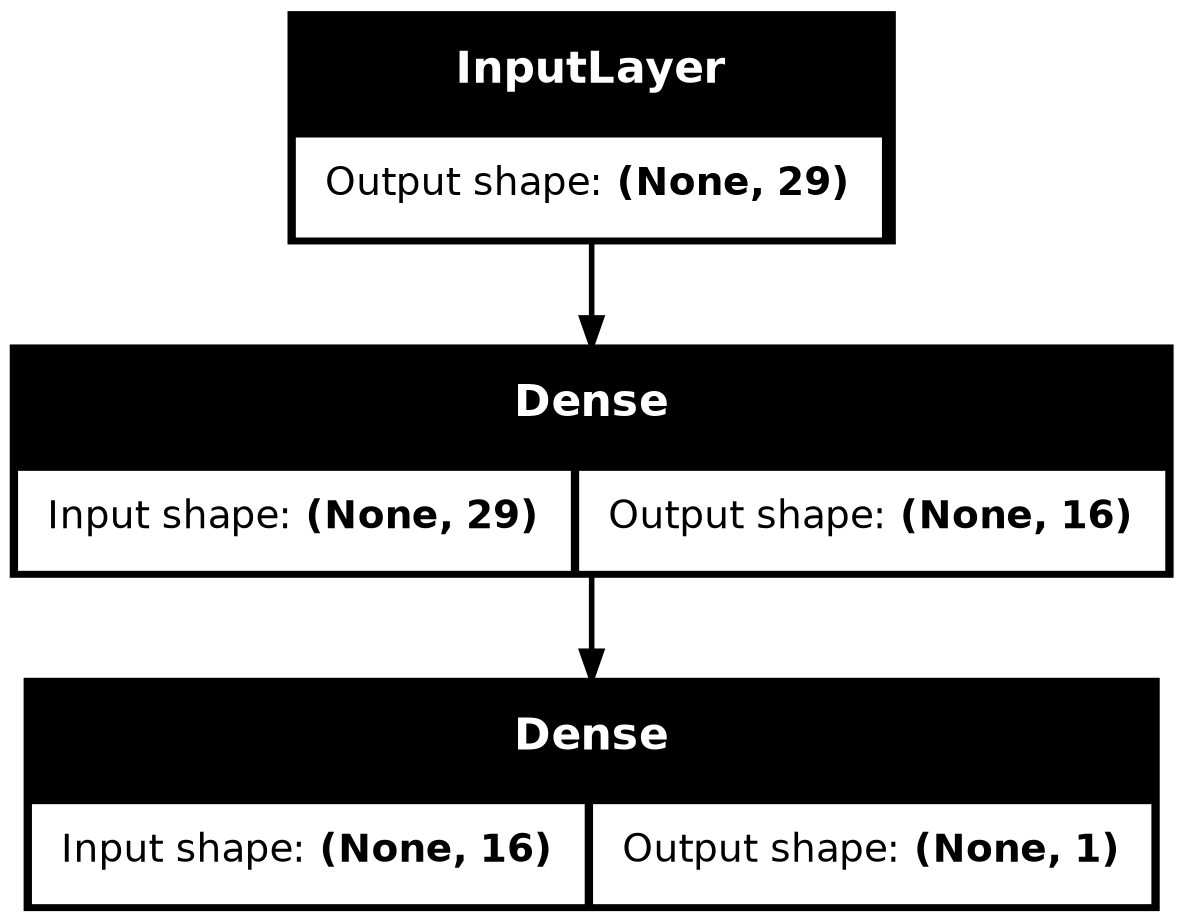

In [18]:
keras.utils.plot_model(model,show_shapes=True)

In [28]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_X,train_Y,
                    epochs=300,batch_size=32,
                    verbose=1,validation_split=0.2)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.5389 - loss: 0.6756 - val_accuracy: 0.5102 - val_loss: 0.6929
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6425 - loss: 0.6317 - val_accuracy: 0.5714 - val_loss: 0.6654
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7254 - loss: 0.5961 - val_accuracy: 0.6531 - val_loss: 0.6421
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7772 - loss: 0.5643 - val_accuracy: 0.6531 - val_loss: 0.6216
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7979 - loss: 0.5358 - val_accuracy: 0.6531 - val_loss: 0.6038
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8031 - loss: 0.5101 - val_accuracy: 0.6735 - val_loss: 0.5878
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8031 - loss: 0.4871 - val_accuracy: 0.6939 - val_loss: 0.5732
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8031 - loss: 0.4665 - val_accuracy: 0.7143 - val_loss

In [29]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

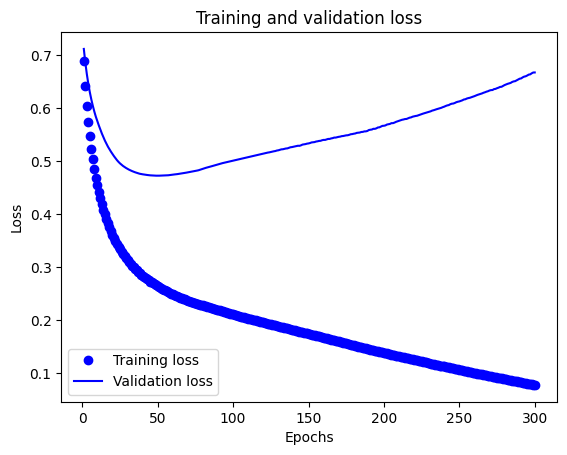

In [21]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

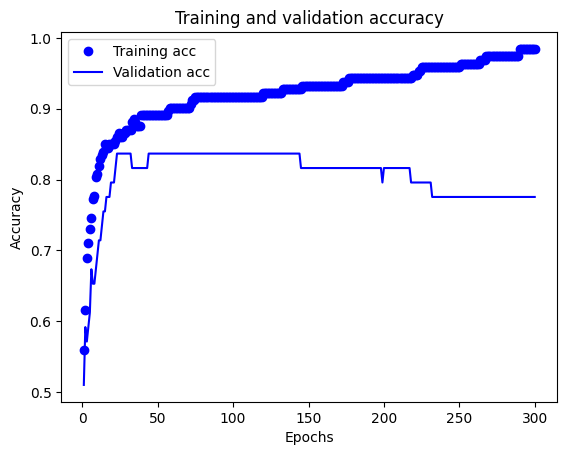

In [22]:
# https://github.com/fchollet/deep-learning-with-python-notebooks/

plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [31]:

model.evaluate(test_X,test_Y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8197 - loss: 0.5380


[0.5380479097366333, 0.8196721076965332]